StatementMeta(, 3c6b7cb3-7843-4e96-aca8-1d4d83ed1a4b, 9, Finished, Available, Finished, False)

root
 |-- TransactionID: string (nullable = true)
 |-- AccountID: string (nullable = true)
 |-- TransactionAmount: double (nullable = true)
 |-- TransactionDate: timestamp (nullable = true)
 |-- TransactionType: string (nullable = true)
 |-- Location: string (nullable = true)
 |-- DeviceID: string (nullable = true)
 |-- IP_Address: string (nullable = true)
 |-- MerchantID: string (nullable = true)
 |-- Channel: string (nullable = true)
 |-- CustomerAge: integer (nullable = true)
 |-- CustomerOccupation: string (nullable = true)
 |-- TransactionDuration: integer (nullable = true)
 |-- LoginAttempts: integer (nullable = true)
 |-- AccountBalance: double (nullable = true)
 |-- PreviousTransactionDate: timestamp (nullable = true)



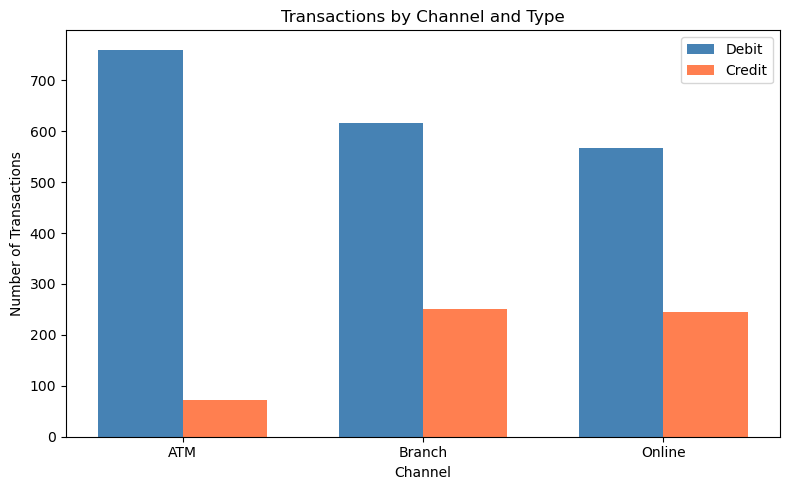

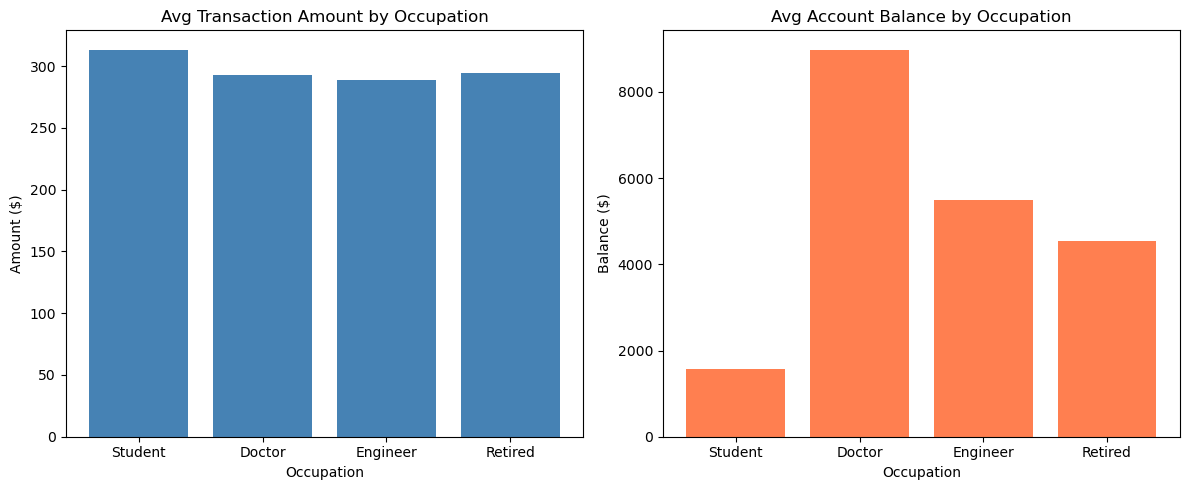

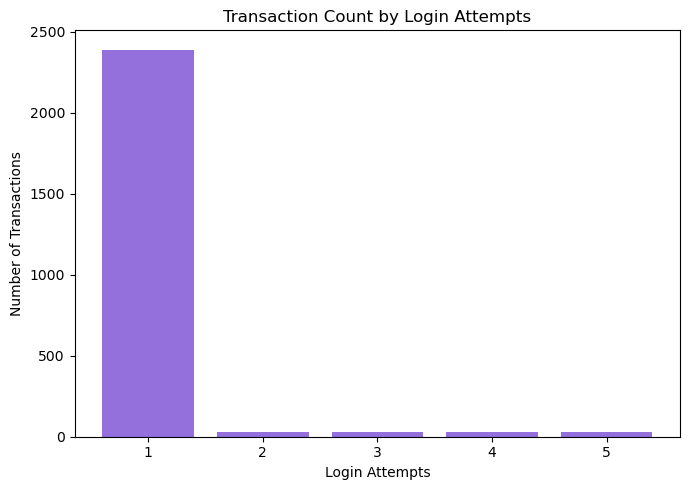

In [4]:
# ============================================================
# Bank Transactions - Fraud Detection Analysis
# Microsoft Fabric Lakehouse | PySpark + Matplotlib
# ============================================================

from pyspark.sql.functions import col, count, when, avg, sum
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Load Data
# ------------------------------------------------------------
df = spark.read.table("bank_transactions")
df.printSchema()

# ------------------------------------------------------------
# 2. Basic Statistics
# ------------------------------------------------------------
df.select("TransactionAmount", "CustomerAge", "TransactionDuration", "LoginAttempts", "AccountBalance") \
    .describe() \
    .toPandas()

# ------------------------------------------------------------
# 3. Check for Null Values
# ------------------------------------------------------------
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).toPandas()

# ------------------------------------------------------------
# 4. Transactions by Channel and Type
# ------------------------------------------------------------
df.groupBy("Channel", "TransactionType") \
    .count() \
    .orderBy("Channel") \
    .toPandas()

# ------------------------------------------------------------
# 5. Login Attempts Analysis (Fraud Indicator)
# ------------------------------------------------------------
df.groupBy("LoginAttempts") \
    .agg(
        count("TransactionID").alias("NumTransactions"),
        avg("TransactionAmount").alias("AvgAmount")
    ) \
    .orderBy(col("LoginAttempts").desc()) \
    .toPandas()

# ------------------------------------------------------------
# 6. Occupation Analysis
# ------------------------------------------------------------
df.groupBy("CustomerOccupation") \
    .agg(
        count("TransactionID").alias("NumTransactions"),
        avg("TransactionAmount").alias("AvgAmount"),
        avg("AccountBalance").alias("AvgBalance")
    ) \
    .orderBy(col("AvgAmount").desc()) \
    .toPandas()

# ------------------------------------------------------------
# 7. Suspicious Transactions (LoginAttempts > 1)
# ------------------------------------------------------------
df.filter(df.LoginAttempts > 1) \
    .select("TransactionID", "AccountID", "TransactionAmount", "Location", "Channel", "LoginAttempts") \
    .orderBy(col("LoginAttempts").desc()) \
    .toPandas()

# ------------------------------------------------------------
# 8. Plot 1: Grouped Bar - Transactions by Channel and Type
# ------------------------------------------------------------
ch_df = df.groupBy("Channel", "TransactionType") \
    .agg(count("TransactionID").alias("Count")) \
    .orderBy("Channel") \
    .toPandas()

channels = ch_df["Channel"].unique()
debit = ch_df[ch_df["TransactionType"] == "Debit"]["Count"].values
credit = ch_df[ch_df["TransactionType"] == "Credit"]["Count"].values

x = np.arange(len(channels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, debit, width, label="Debit", color="steelblue")
ax.bar(x + width/2, credit, width, label="Credit", color="coral")
ax.set_title("Transactions by Channel and Type")
ax.set_xlabel("Channel")
ax.set_ylabel("Number of Transactions")
ax.set_xticks(x)
ax.set_xticklabels(channels)
ax.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Plot 2: Occupation vs Avg Amount and Balance
# ------------------------------------------------------------
occ_df = df.groupBy("CustomerOccupation") \
    .agg(
        avg("TransactionAmount").alias("AvgAmount"),
        avg("AccountBalance").alias("AvgBalance")
    ) \
    .toPandas()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].bar(occ_df["CustomerOccupation"], occ_df["AvgAmount"], color="steelblue")
ax[0].set_title("Avg Transaction Amount by Occupation")
ax[0].set_xlabel("Occupation")
ax[0].set_ylabel("Amount ($)")

ax[1].bar(occ_df["CustomerOccupation"], occ_df["AvgBalance"], color="coral")
ax[1].set_title("Avg Account Balance by Occupation")
ax[1].set_xlabel("Occupation")
ax[1].set_ylabel("Balance ($)")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. Plot 3: Login Attempts Distribution
# ------------------------------------------------------------
login_df = df.groupBy("LoginAttempts") \
    .count() \
    .orderBy("LoginAttempts") \
    .toPandas()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(login_df["LoginAttempts"].astype(str), login_df["count"], color="mediumpurple")
ax.set_title("Transaction Count by Login Attempts")
ax.set_xlabel("Login Attempts")
ax.set_ylabel("Number of Transactions")
plt.tight_layout()
plt.show()